In [50]:
from epaisseur_module import get_datacube, calcul, infos_from_csv
import matplotlib.pyplot as plt
import numpy as np
from arsf_envi_reader import envi_header
from scipy.signal import savgol_filter
import matplotlib as mpl
import pandas as pd
from optifik.minmax import thickness_from_minmax
import seaborn as sns

On acquiert le spectre de la lumière réfléchie sur un film liquide mince, à l'aide d'une caméra hyperspectrale, sur une ligne spatiale et en temps.
Les données issues de la caméra consistent en un datacube contenant la valeur de l'intensité lumineuse en fonction de la longueur d'onde, du temps et de l'espace.
Ici on propose de calculer l'épaisseur du film mince en un point d'espace et de temps.


Préalable au calcul

In [51]:
# fichier
file_bil = "26-10-23/500 rpm tige 250 lendemain matin"

# récupération des données du header
hdr = envi_header.read_hdr_file(file_bil+'.hdr', keep_case=False) #type dictionnaire
n_temps = int(hdr['lines'])
n_espace = int(hdr['samples'])
file_bil = file_bil + ".bil"

#outliers
prop_max_outliers = 1

#détection des min et max
prominence = 100
distance = 1

#indice de réfraction huile silicone
n = 1.52045

Calcul de l'épaisseur

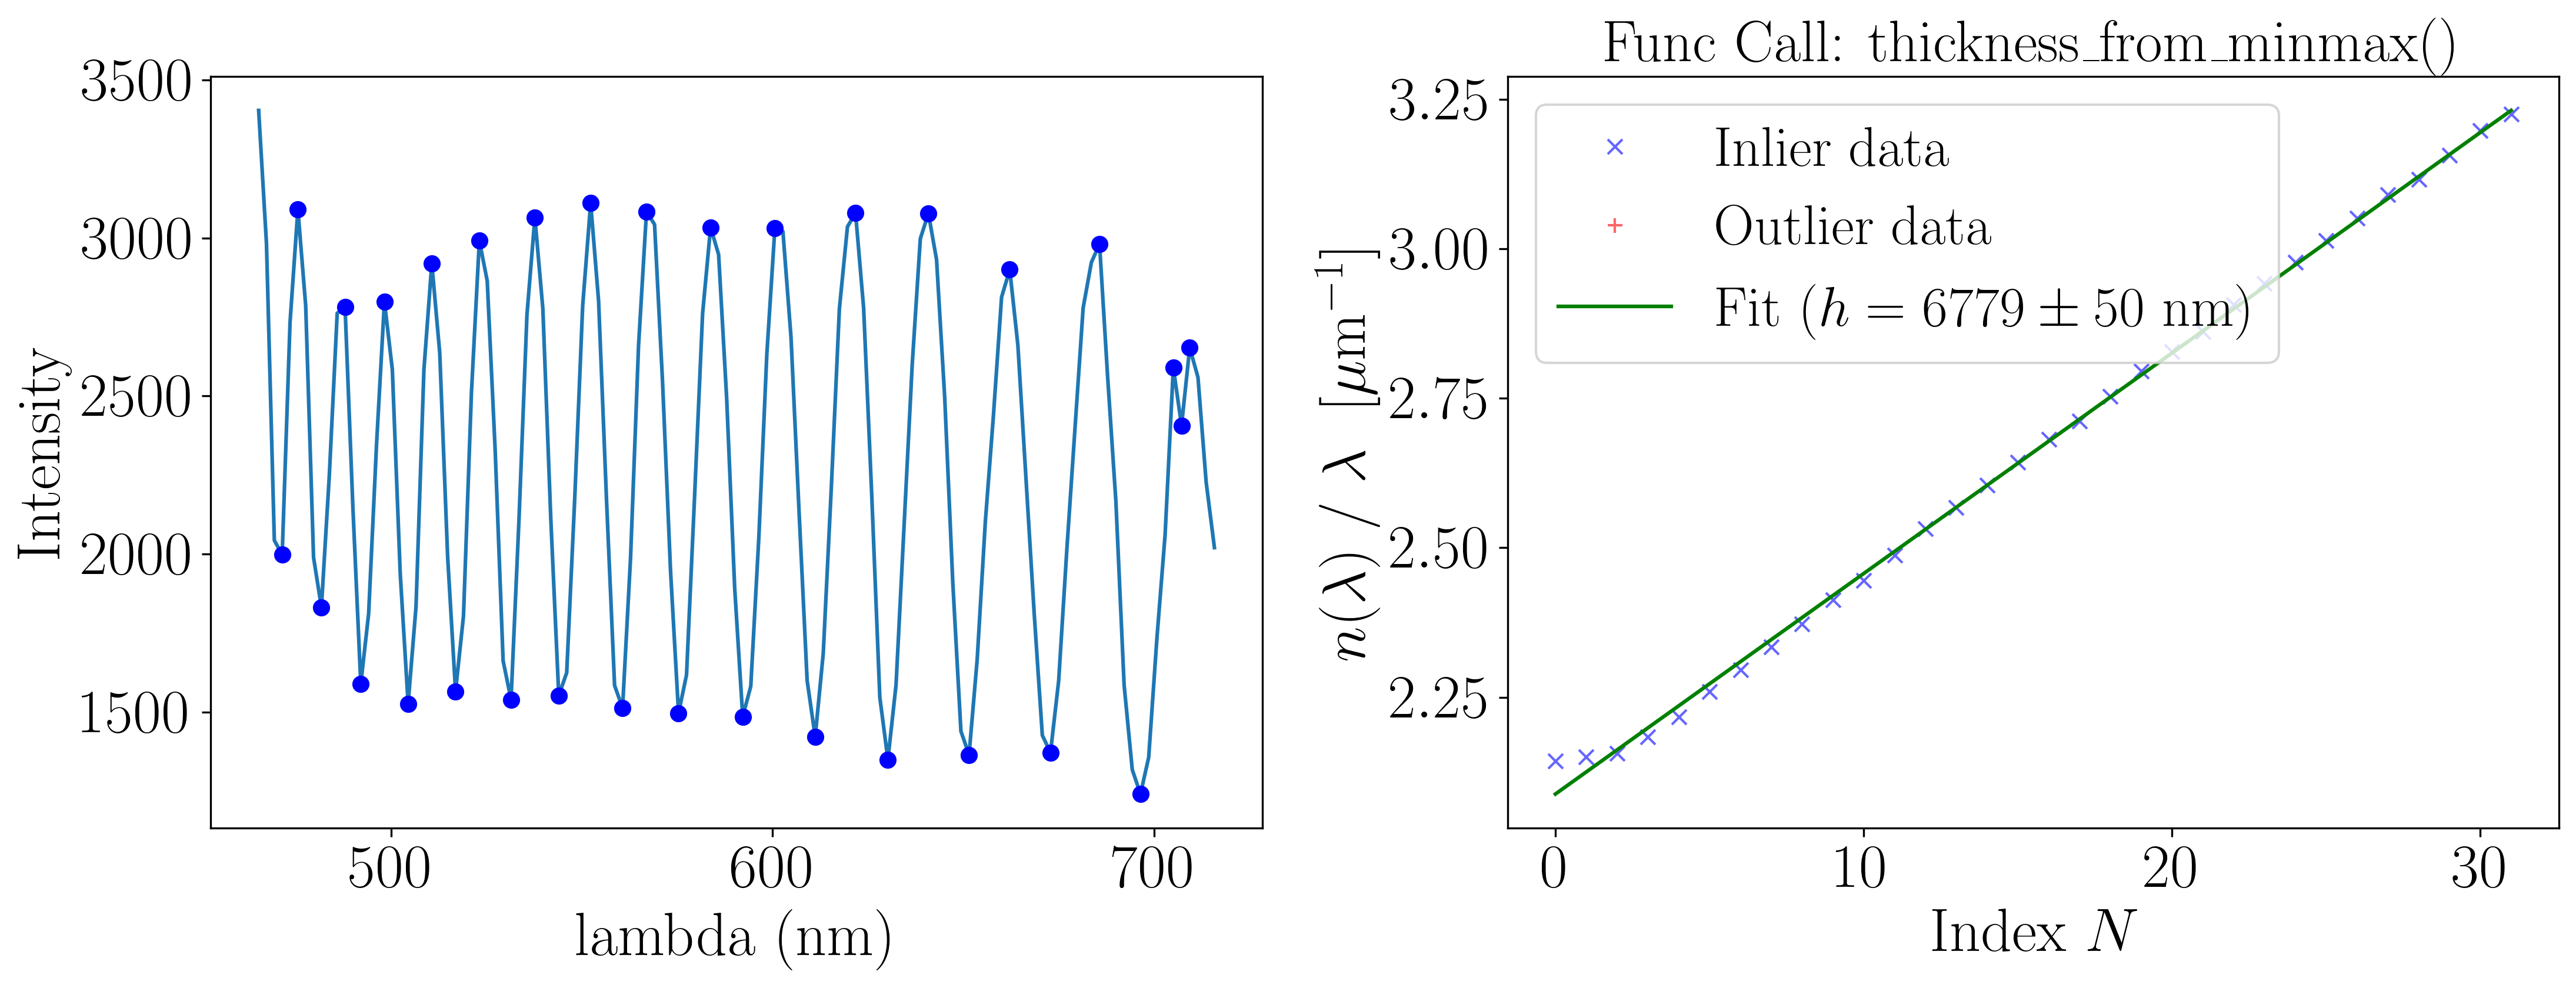

épaisseur = 6778.529516923534 nm


In [52]:
#choix du point
i_espace = 30 #sample
i_temps  = 0 #line
#lissage du spectre
window = None

# calculer l'épaisseur en un point
[datacube,n_temps,n_espace,n_lambdas,v_temps,v_espace,v_lambdas] = get_datacube(file_bil)
gauche = 40 #pour crop en lambdas
droite = 160
v_lambdas = v_lambdas[gauche:droite]
datacube = datacube[:,:,gauche:droite]

#lissage du spectre
if window != None:
    datacube = savgol_filter(datacube,window,3)

epaisseur,prop_outliers = calcul(datacube,v_lambdas,prominence,distance,i_temps,i_espace,prop_max_outliers,1,n)
print('épaisseur =',epaisseur,'nm')

On utilise le module optifik qui détecte les minima et maxima du spectre (figure de gauche).
Optifik fait une régression linéaire faisant intervenir les valeurs des longueurs d'ondes où sont atteints ces extrema. La valeur de l'épaisseur du film est contenue dans la pente de cette régression linéaire.
On obtient que l'épaisseur du film vaut 7 micromètres.

En calculant l'épaisseur sur tout le datacube (espace, temps) on peut tracer plusieurs profils d'épaisseur, c'est-à-dire des courbes de l'épaisseur en fonction de la coordonnée spatiale, à différents instants :

proportion de spectres gardés = 0.666112511395935


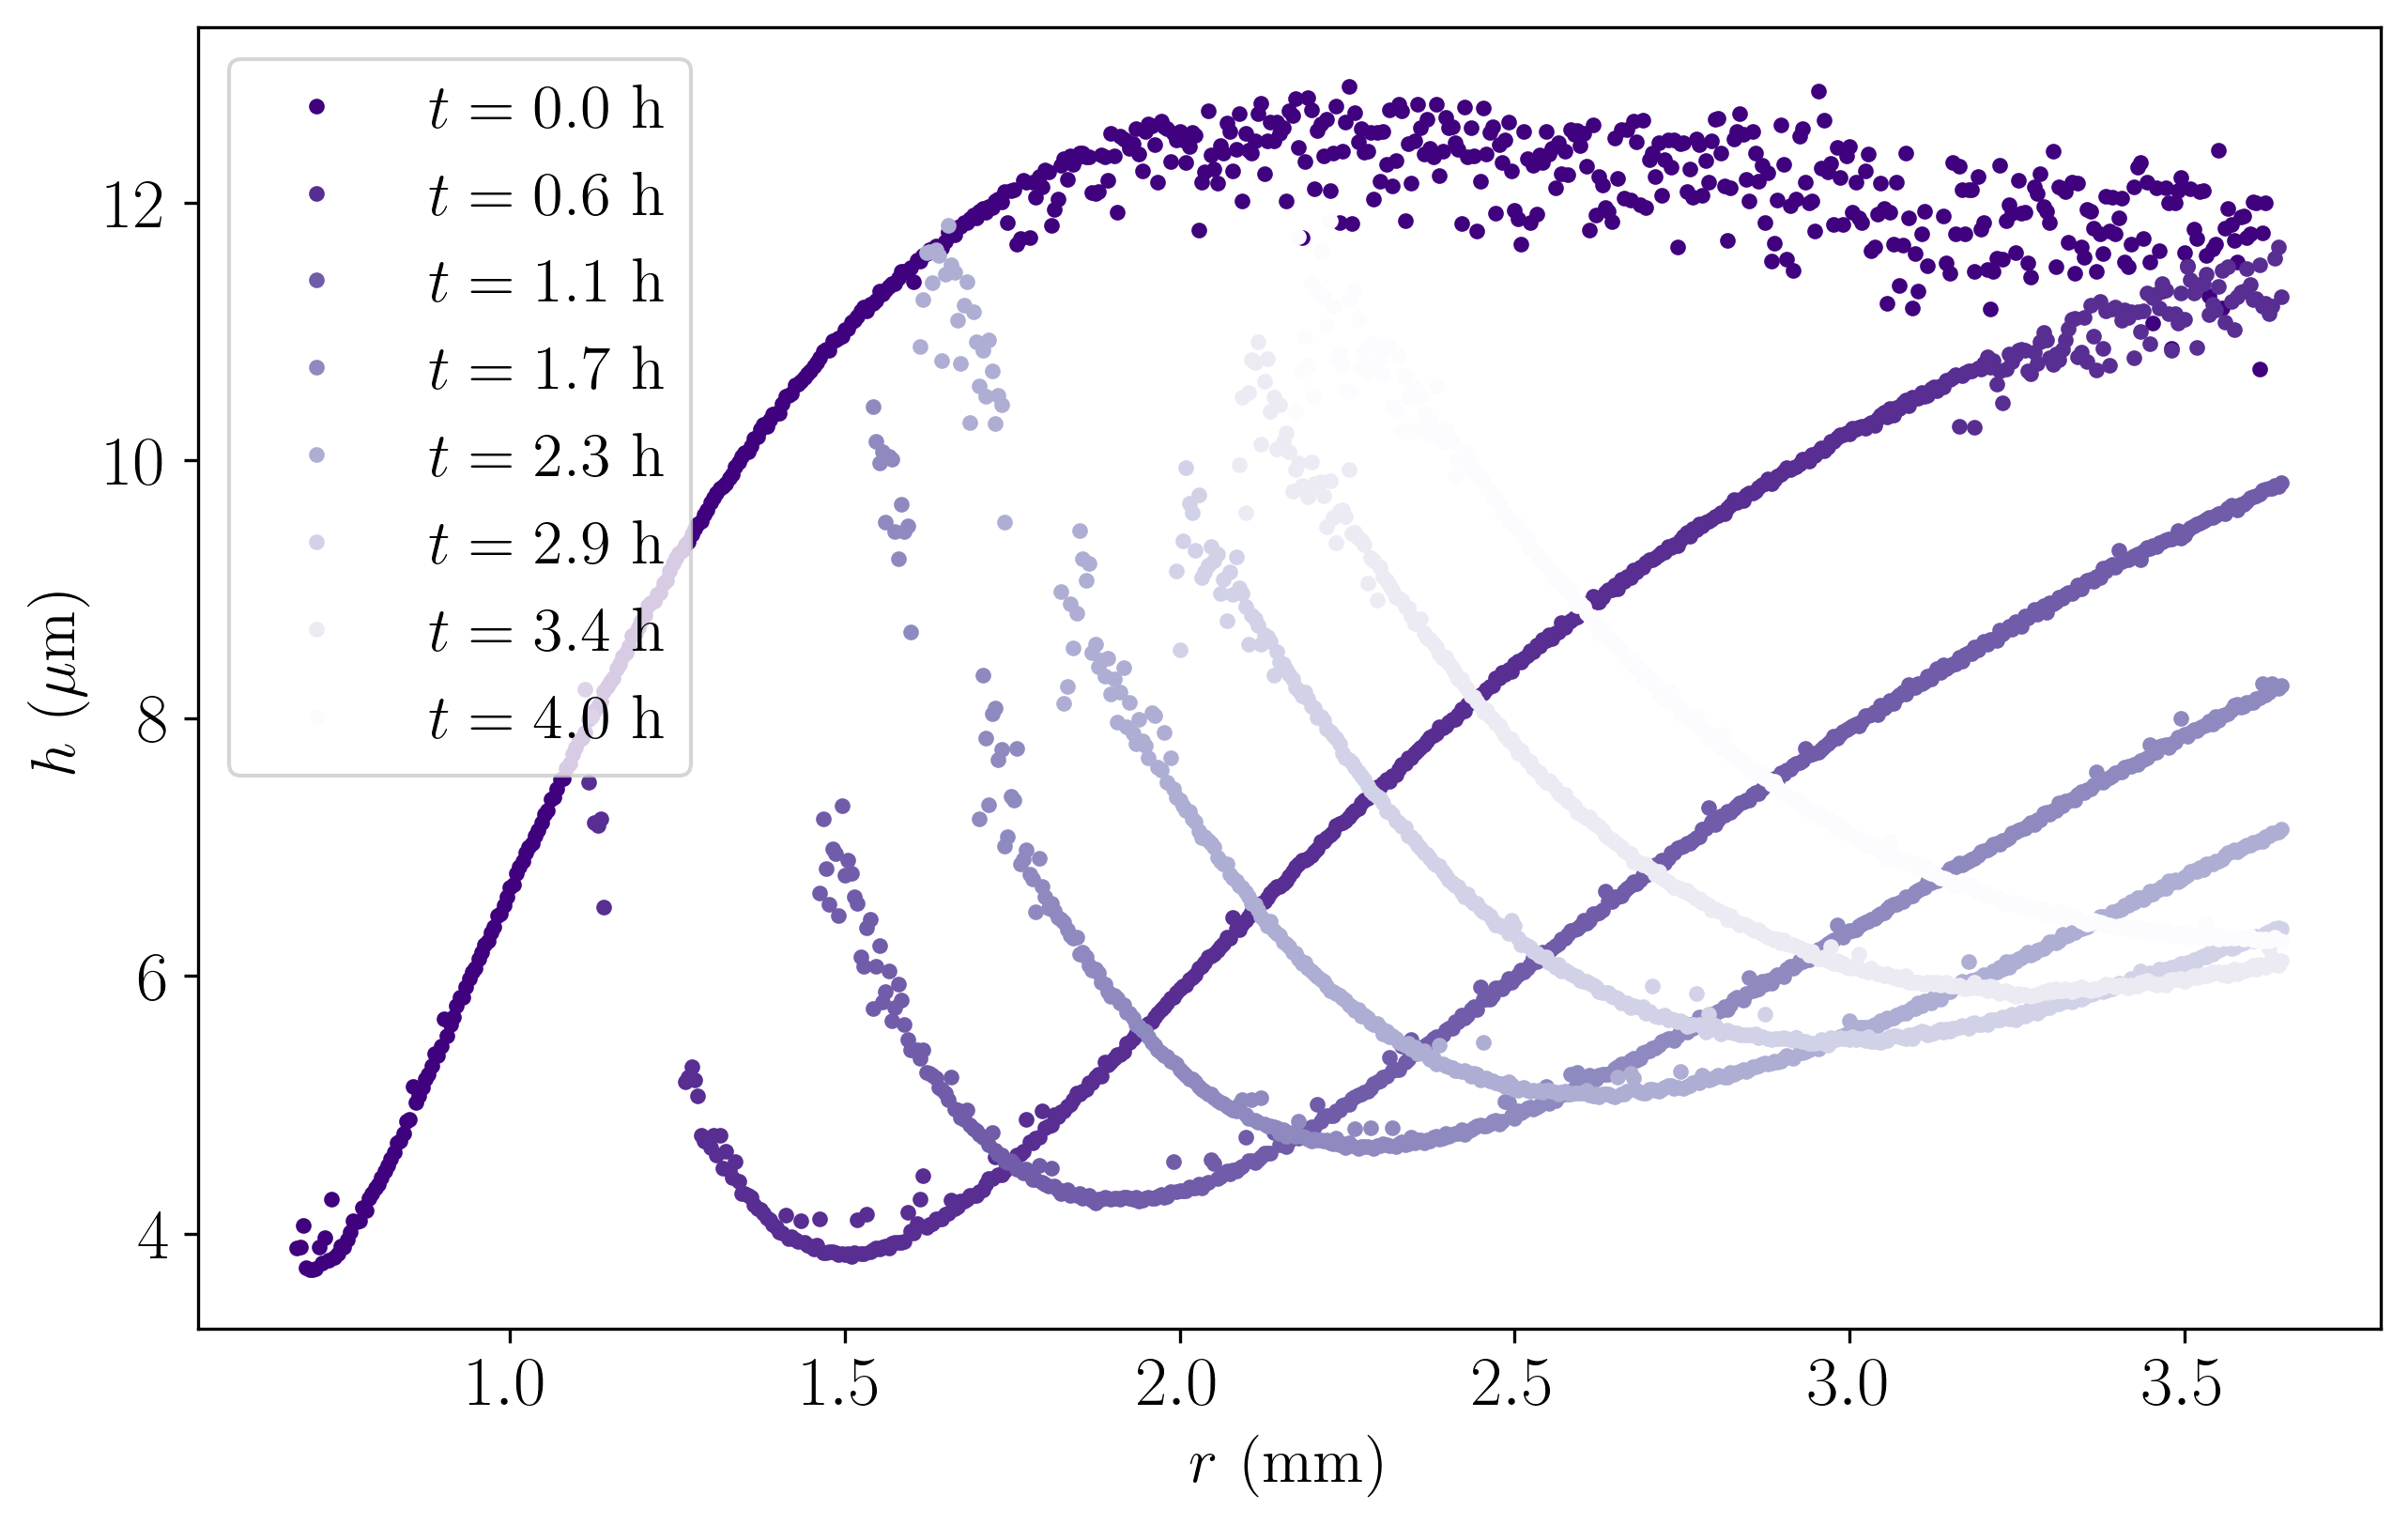

In [53]:
#file
file = '26-10-23/manip2-CropWavelengths-SpatialCrop,10,1,1,100,1,1.52045,spatemps,flip,std3-500,crop138,pisolés8-7,sauts2000,sauts1500.csv'
epaisseurs,v_temps,v_espace,prop_spectres_gardes = infos_from_csv(file)

#plot
fig,ax = plt.subplots()
nbre_lignes = 8

#colormap
#cmap = plt.cm.get_cmap("Purples")
cmap = plt.get_cmap("Purples_r")
norma = mpl.colors.Normalize(vmin=np.min(v_temps), vmax=np.max(v_temps)+10)
sm = mpl.cm.ScalarMappable(norm=norma, cmap=cmap)
sm.set_array([])

#sélection des instants à tracer
temps = np.linspace(1,len(v_temps)-1,nbre_lignes,dtype=int)

for i in temps:
    plt.plot(v_espace*1000,epaisseurs[i,:]/1000,'.', color=cmap(norma(v_temps[i])),label=r'$t = %s ~  \rm{h}$' % format(v_temps[i]/3600, ".1f")) #str(v_temps[temps[i]])

plt.xlabel(r'$r ~ (\textrm{mm})$',fontsize=16)
plt.ylabel(r'$h ~ (\mu \textrm{m})$',fontsize=16)
plt.legend(fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=18)

On voit un creux, que l'on appelle pincement, qui se déplace vers la droite au fur que le temps avance (du violet foncé au violet clair).

On peut repérer le minimum d'épaisseur de ces profils d'épaisseurs, c'est-à-dire l'épaisseur du pincement et la position où il est atteint et les consigner dans un fichier csv :

In [54]:
#file
file = '26-10-23/manip2-CropWavelengths-SpatialCrop,10,1,1,100,1,1.52045,spatemps,flip,std3-500,crop138,pisolés8-7,sauts2000,sauts1500,pincement.csv'

df = pd.read_csv(file)
df

,t (s),t (h),$h_p$ (nm),$h_p$ ($\mu$m),$x_p$ (mm)
0,100.0,0.027778,3719.663814,3.719664,0.705607
1,200.0,0.055556,3623.014665,3.623015,0.789720
2,300.0,0.083333,3595.328229,3.595328,0.883178
3,400.0,0.111111,3583.526446,3.583526,0.943925
4,500.0,0.138889,3586.872572,3.586873,0.976636
...,...,...,...,...,...
139,14000.0,3.888889,6201.147852,6.201148,3.593458
140,14100.0,3.916667,6211.399779,6.211400,3.584112
141,14200.0,3.944444,6240.523403,6.240523,3.630841
142,14300.0,3.972222,6255.948401,6.255948,3.644860


On peut tracer l'épaisseur du pincement en fonction du temps :

Text(0, 0.5, '$h ~ (\\mu \\textrm{m})$')

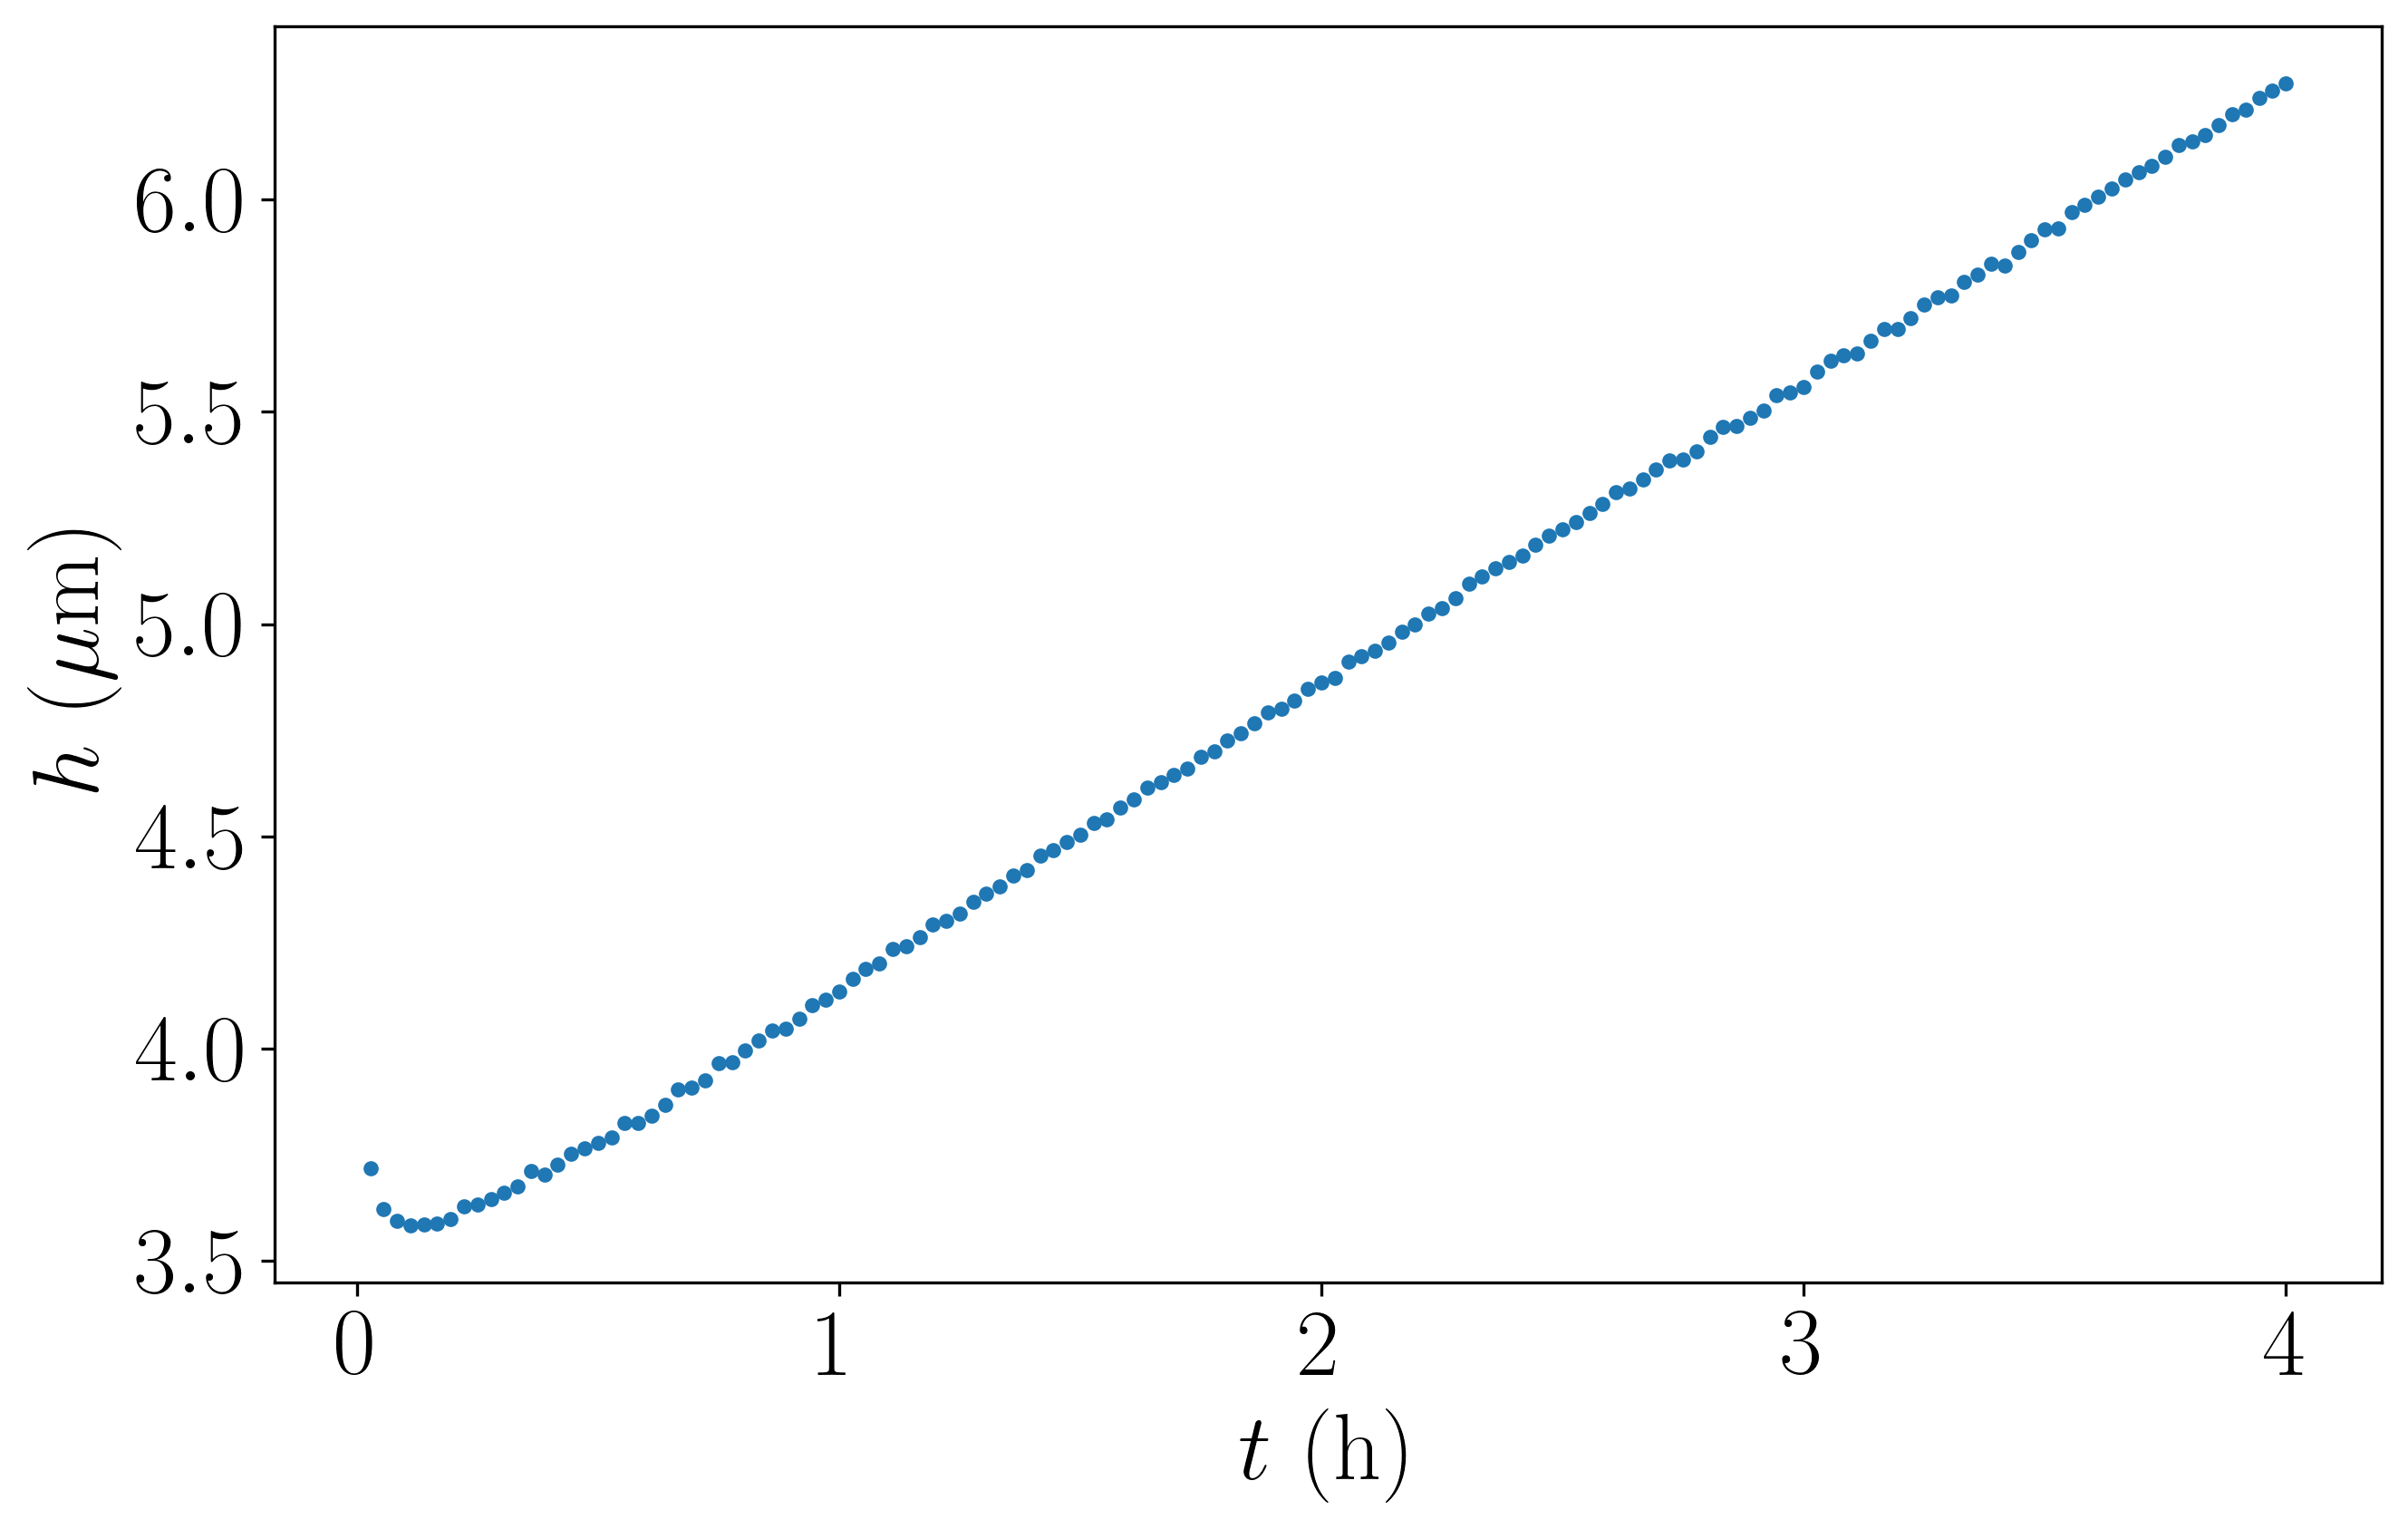

In [55]:
#plot
fig,ax = plt.subplots()
plt.plot(df['t (h)'],df['$h_p$ (nm)']/1000,'.')
plt.xlabel(r'$t ~ (\textrm{h})$')
plt.ylabel(r'$h ~ (\mu \textrm{m})$')

On voit qu'elle diminue puis réaugmente. L'augmentation de h est linéaire. Vérifions avec regplot, à partir du moment où h semble linéaire :

<Axes: xlabel='t (h)', ylabel='$h_p$ (nm)'>

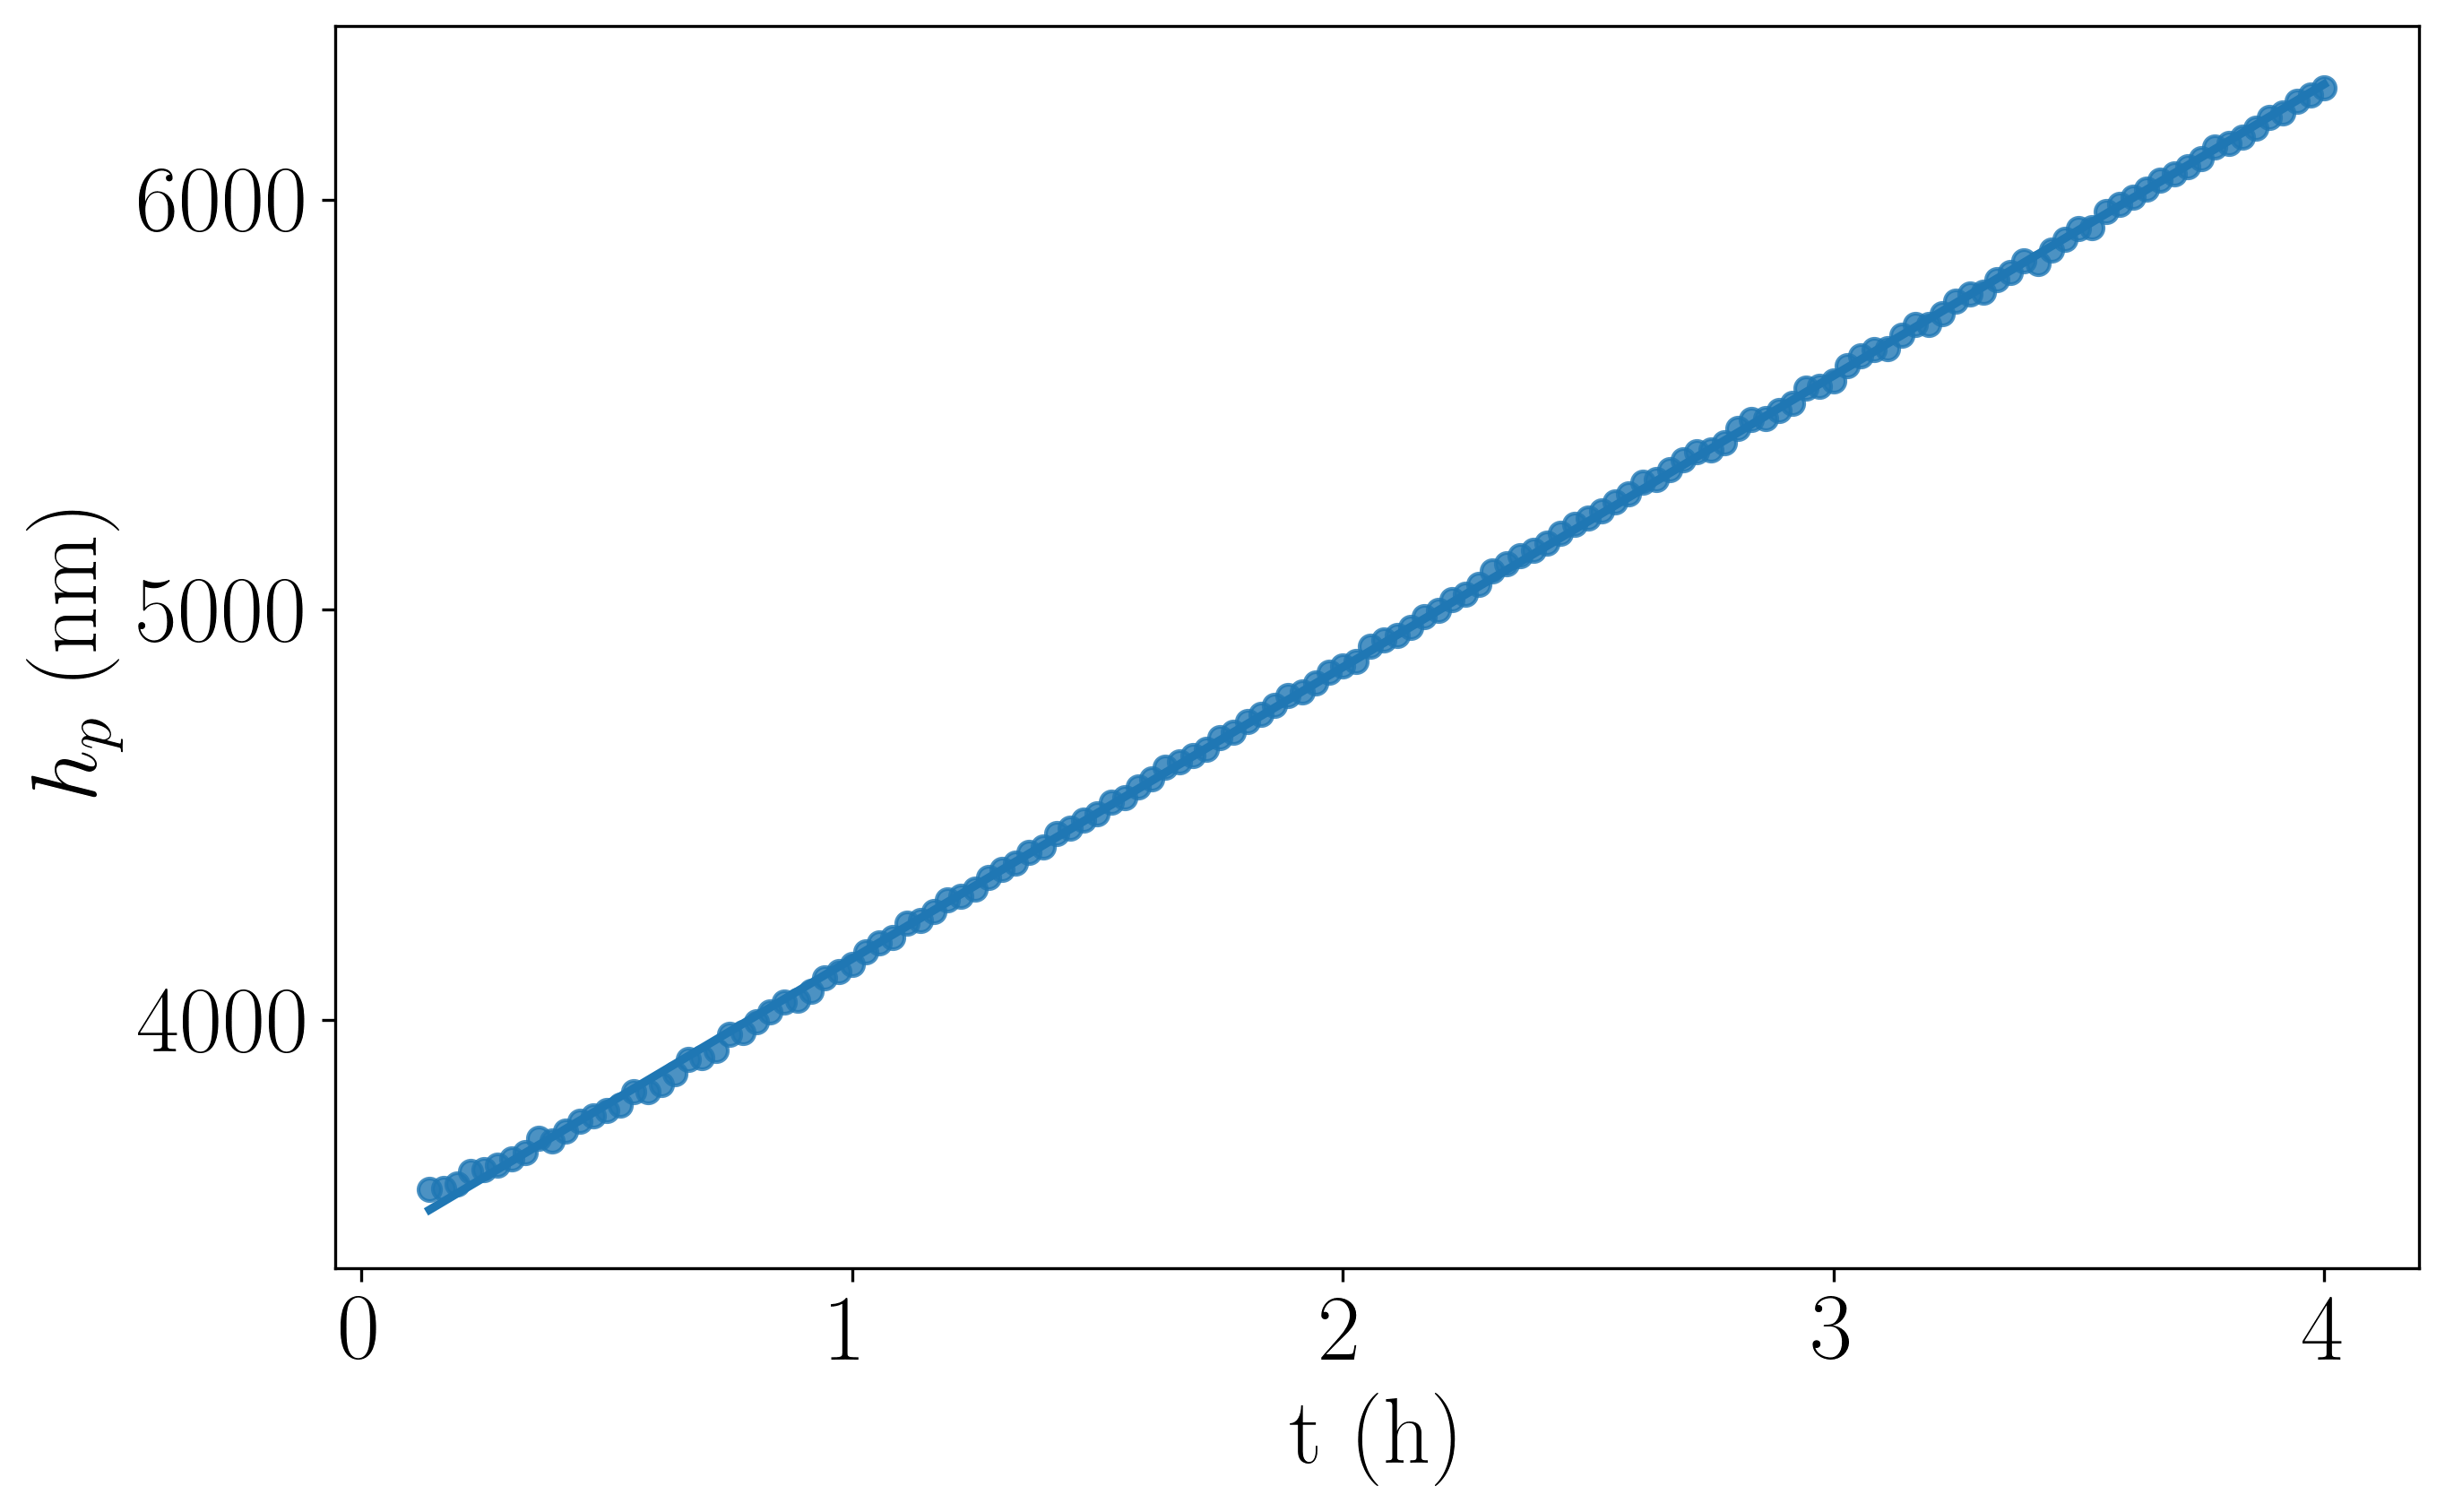

In [65]:
#plot
fig,ax = plt.subplots()
plt.xlabel(r'$t ~ (\textrm{h})$')
plt.ylabel(r'$h ~ (\mu \textrm{m})$')
sns.regplot(df[4:],x='t (h)',y='$h_p$ (nm)')


On fait de même avec la position du pincement en fonction du temps :

Text(0, 0.5, '$x_p ~ (\\textrm{mm})$')

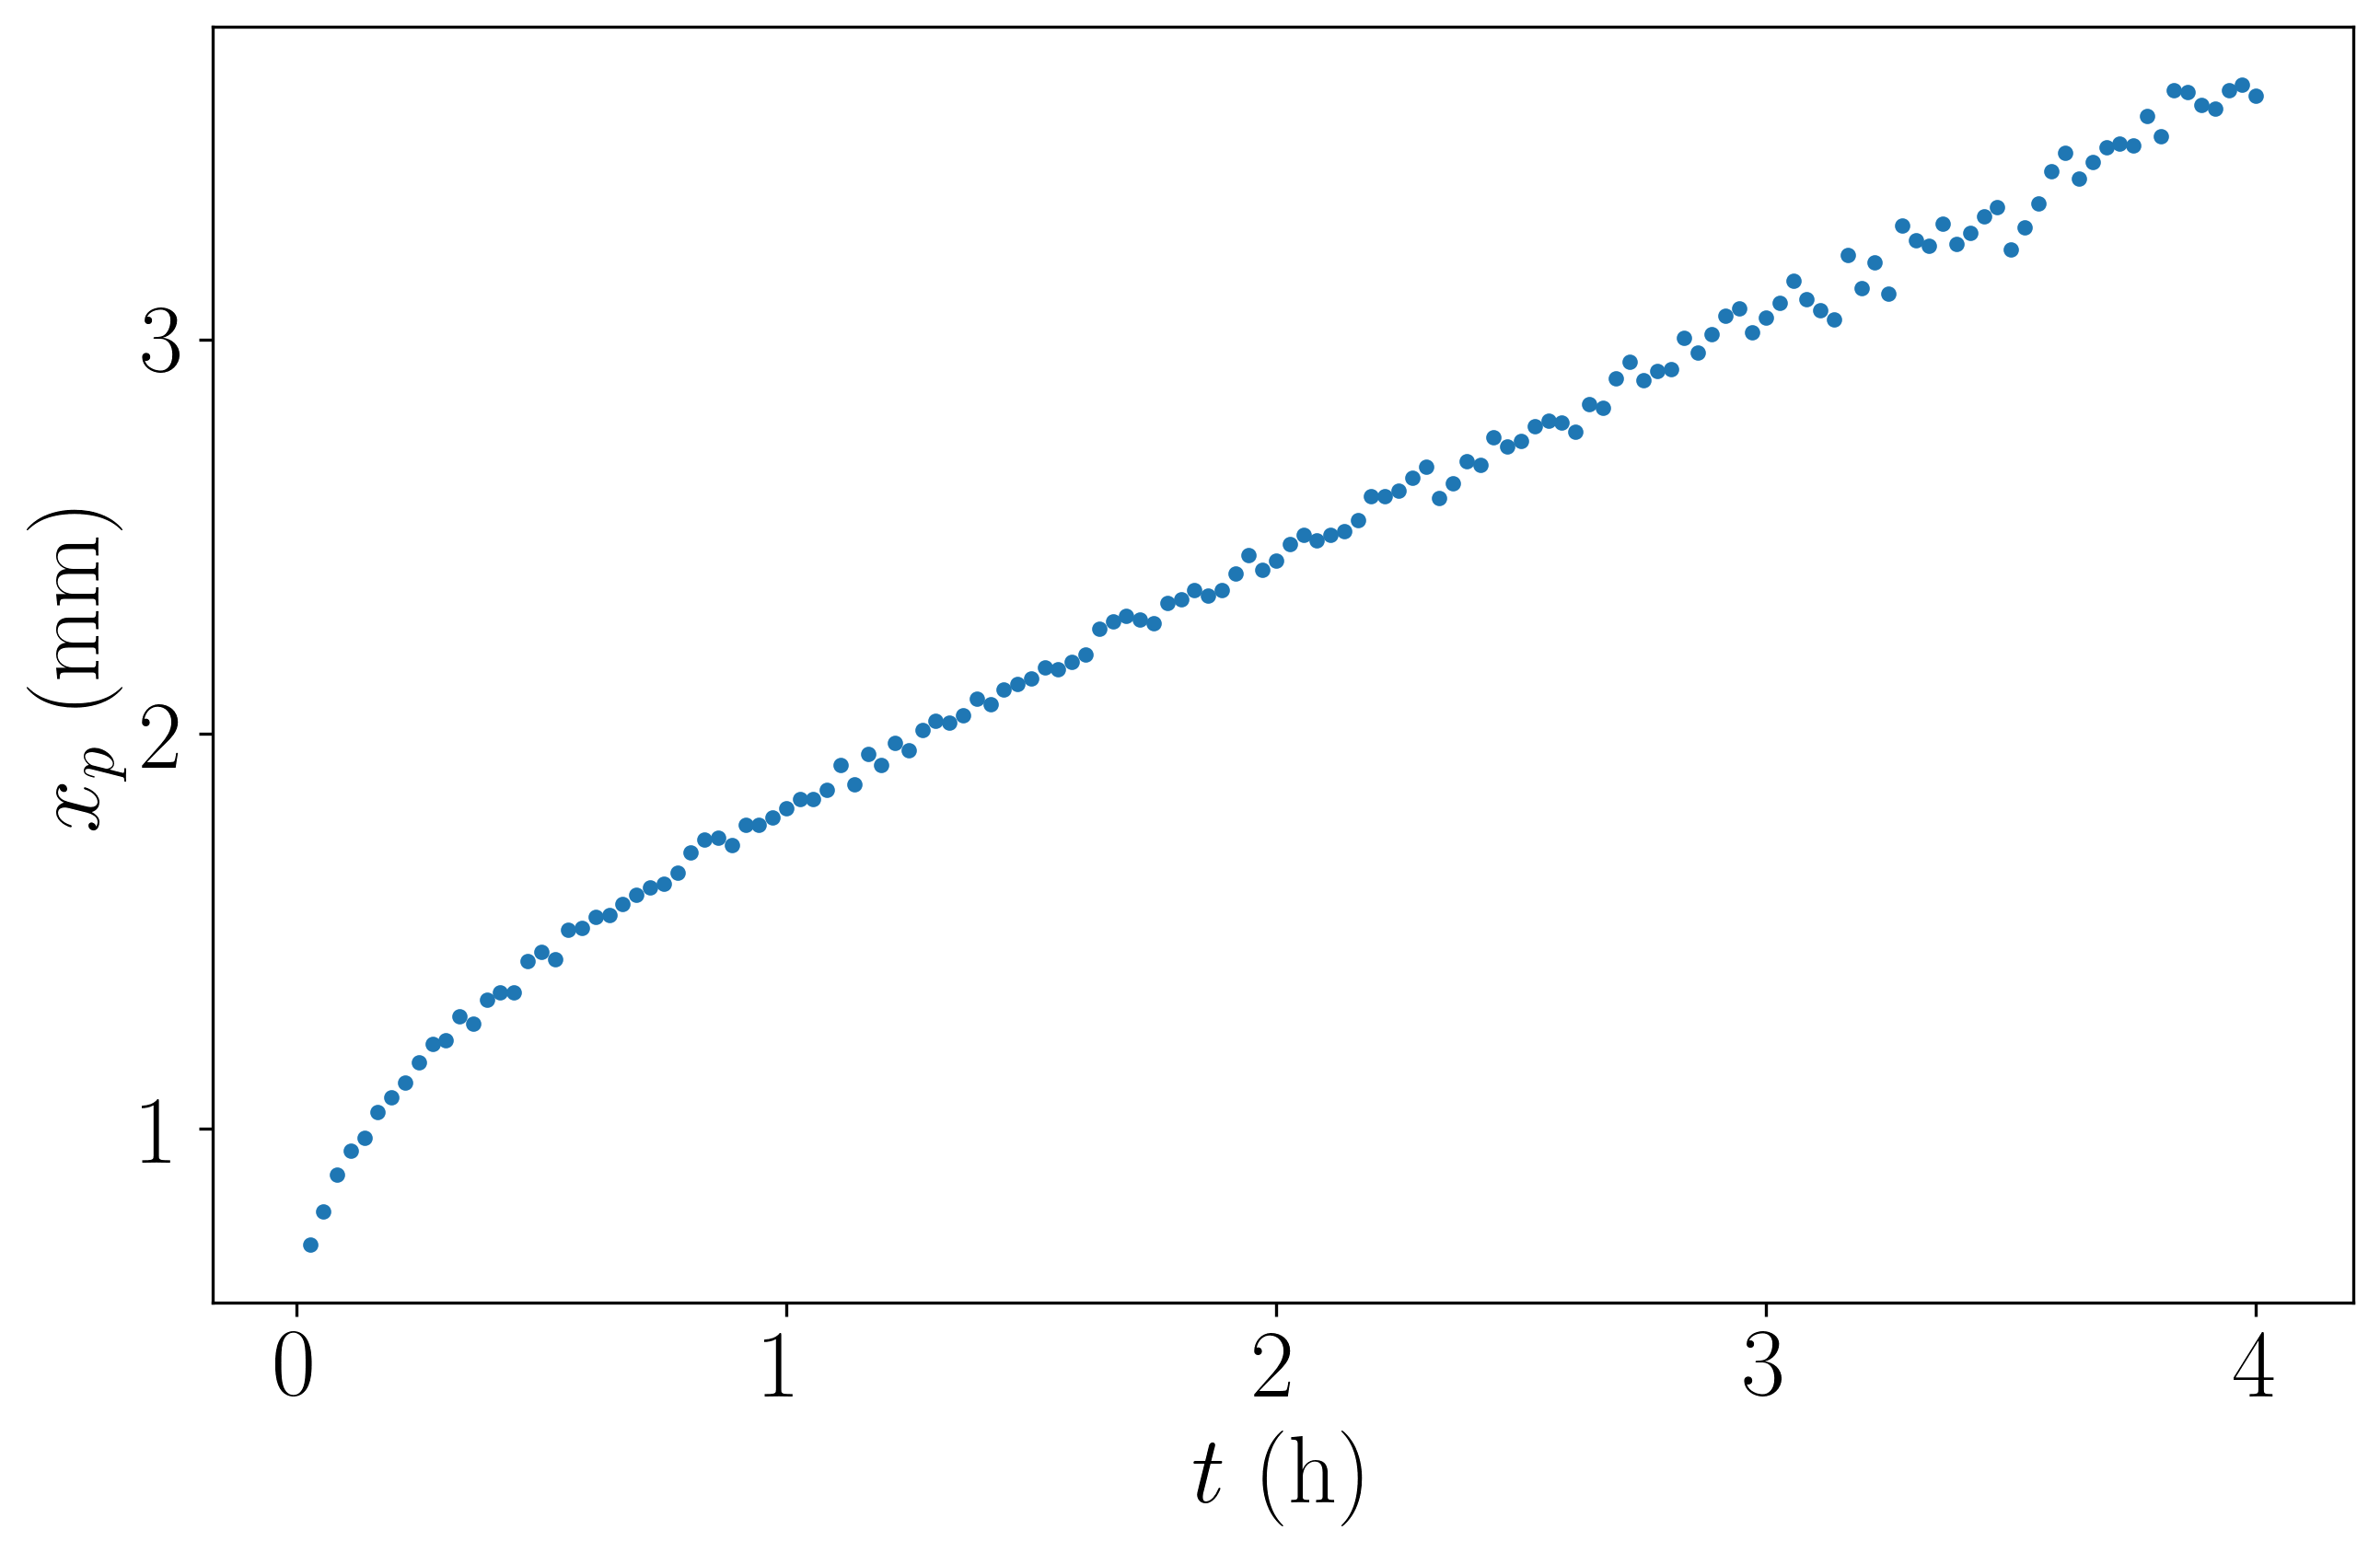

In [57]:
#plot
fig,ax = plt.subplots()
plt.plot(df['t (h)'],df['$x_p$ (mm)'],'.')
plt.xlabel(r'$t ~ (\textrm{h})$')
plt.ylabel(r'$x_p ~ (\textrm{mm})$')

On voit qu'elle augmente tout du long, le pincement se déplace bien vers la droite comme on l'a vu plus tôt. A partir d'un peu avant $t=1h$, l'augmentation de $x_p$ semble linéaire. Vérifions avec regplot :

<Axes: xlabel='t (h)', ylabel='$x_p$ (mm)'>

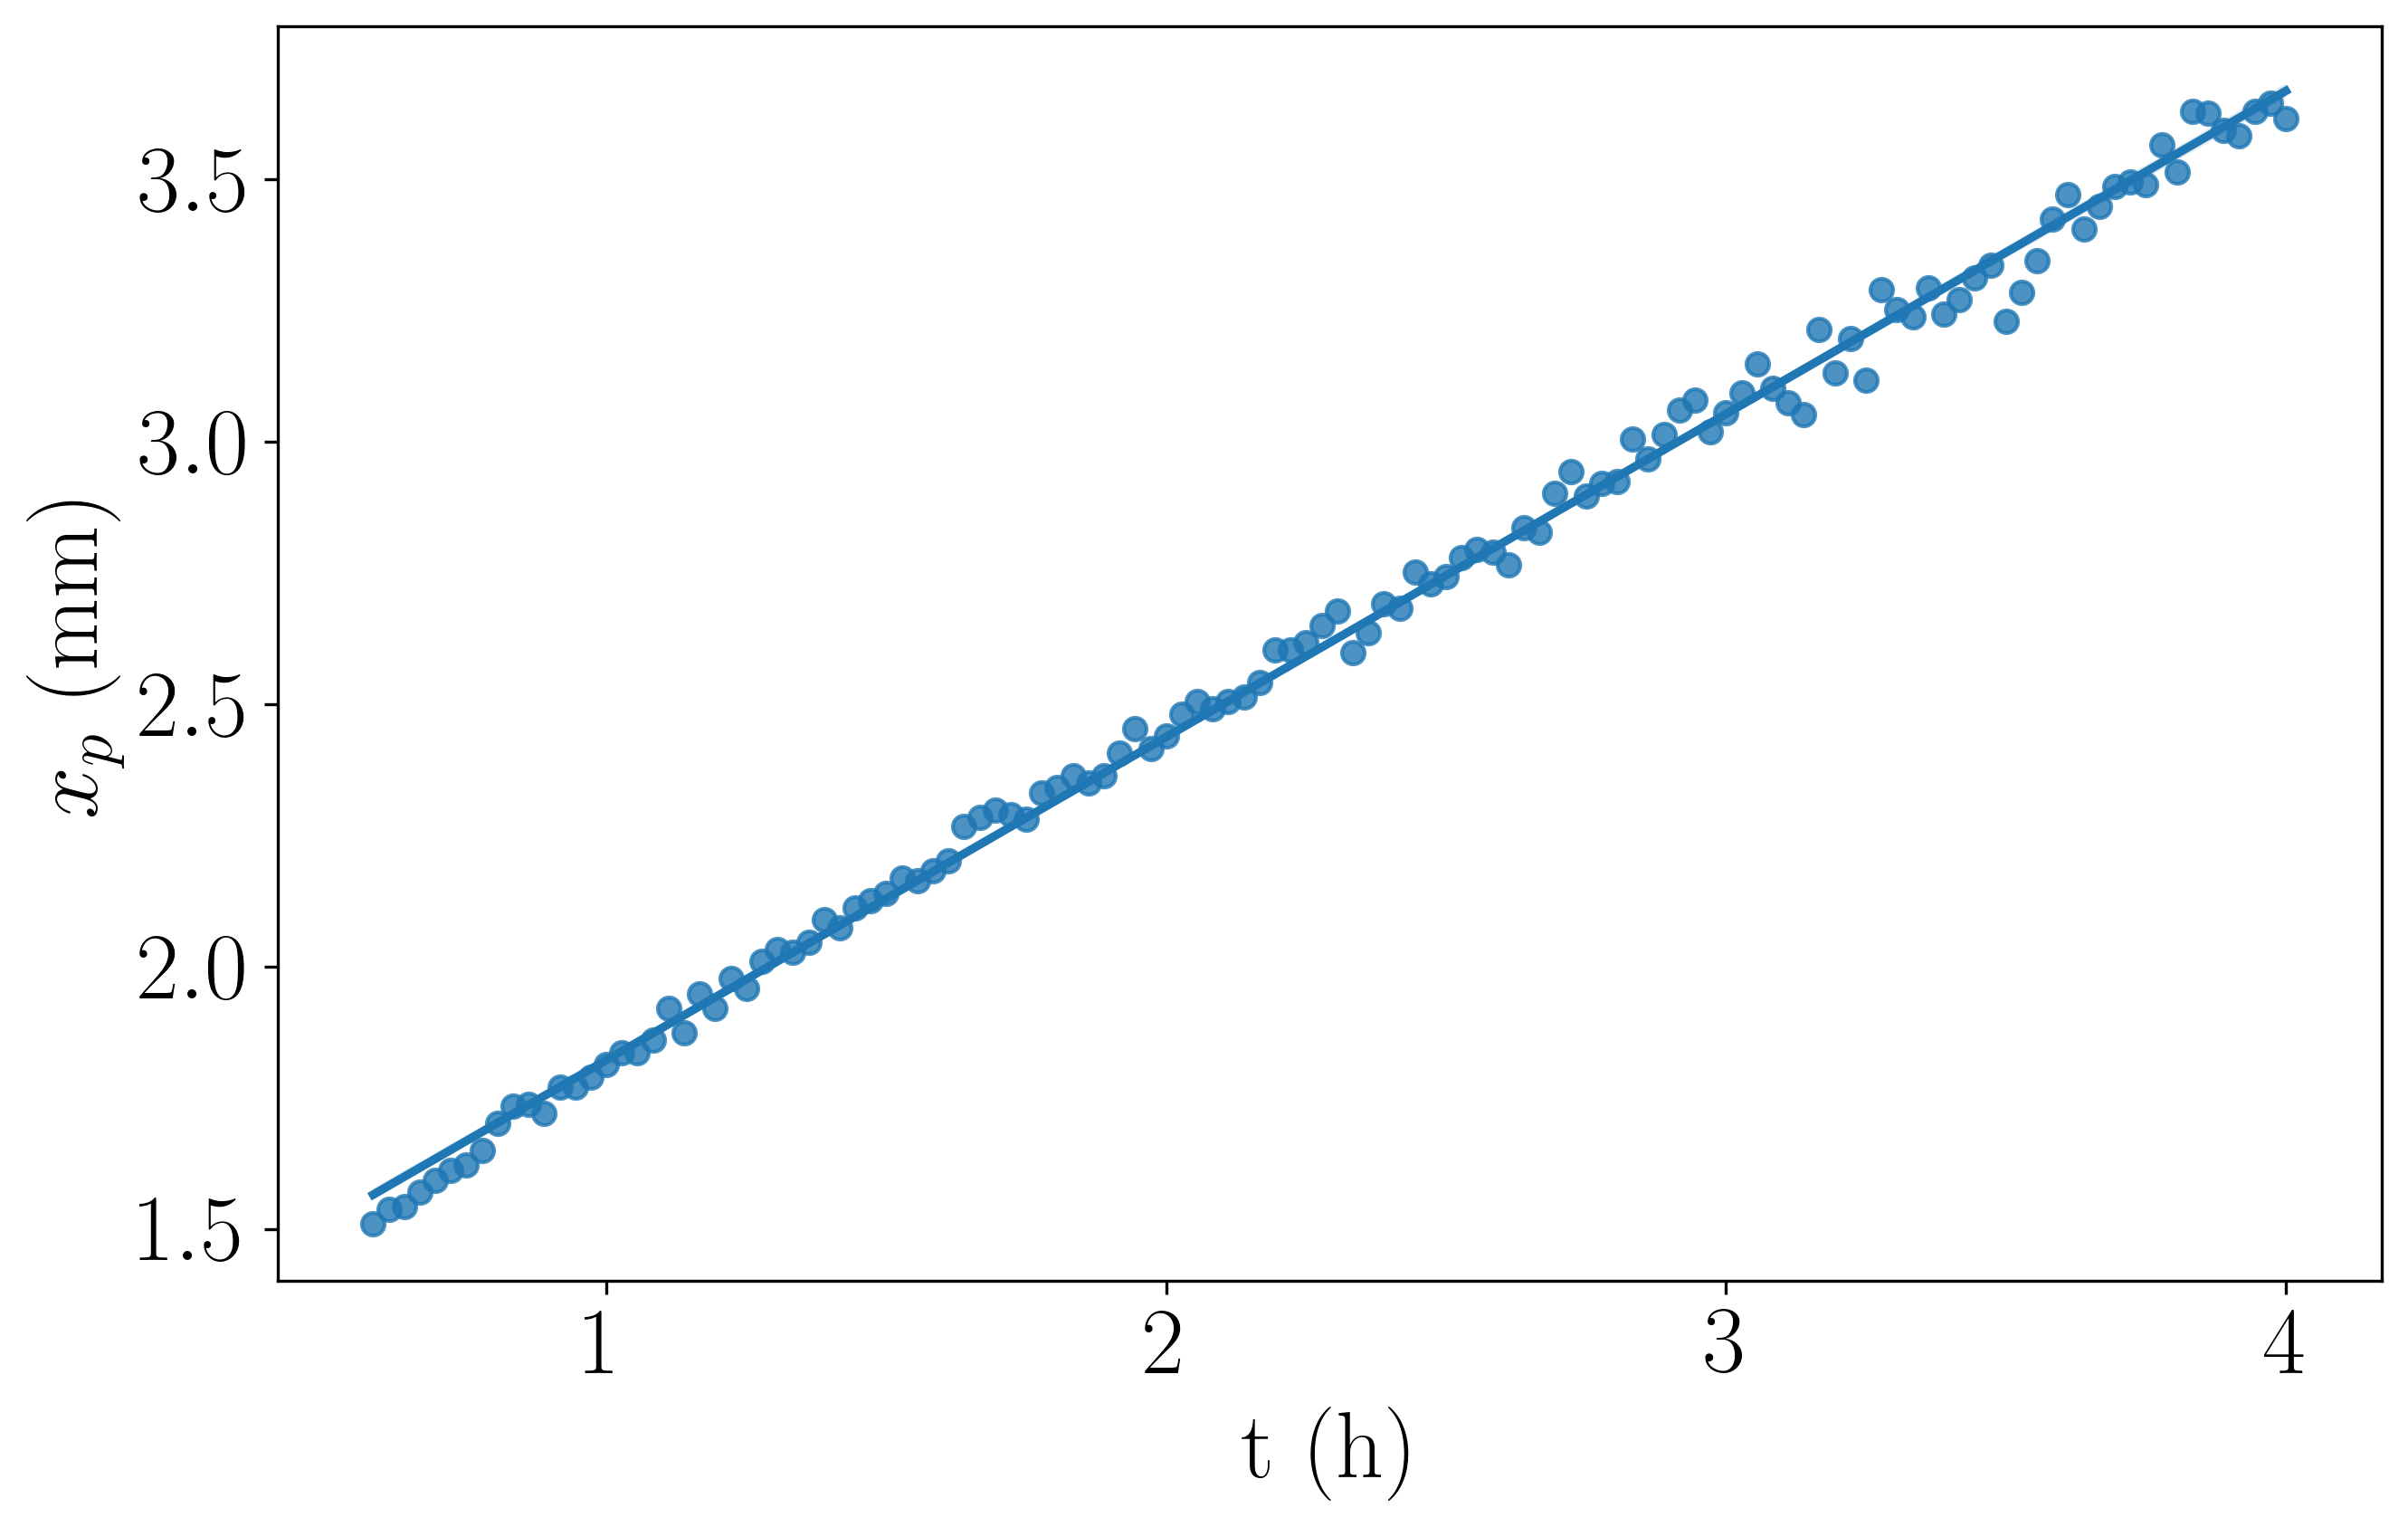

In [64]:
#plot
fig,ax = plt.subplots()
plt.xlabel(r'$t ~ (\textrm{h})$')
plt.ylabel(r'$h ~ (\mu \textrm{m})$')
sns.regplot(df[20:],x='t (h)',y='$x_p$ (mm)')